# Task 1 - BERT Baseline for Music Tag Understanding

This notebook presents the complete Task 1 workflow:

1. inspect MusicCaps caption data and proxy tags,
2. verify multi-label targets and deterministic splits,
3. explain the BERT + linear classification architecture,
4. inspect measured F1 curves and saved metrics,
5. run checkpoint inference, and
6. optionally retrain into a separate output directory.

> **Critical limitation:** these proxy labels are deterministic keyword matches from the same captions given to BERT. High F1 measures recovery of lexical rules, not independent music or audio understanding.

## 1. Environment and imports

In [1]:
from pathlib import Path
import json
import sys

ROOT = Path.cwd().resolve()
if ROOT.name == 'notebooks':
    ROOT = ROOT.parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))
print('Repository root:', ROOT)
# %pip install -r {ROOT / 'requirements.txt'}

Repository root: C:\Users\Roman\OneDrive\Documents\Neural_Project


In [2]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from IPython.display import Image, display

from src.task1.data import TAG_VOCAB, build_tag_frame, extract_tags
from src.task1.predict import predict
from src.task1.train import Task1Config, load_tag_data, make_split_indices, train

print('PyTorch:', torch.__version__)
print('CUDA available:', torch.cuda.is_available())
print('Configured proxy vocabulary:', len(TAG_VOCAB), 'tags')

C:\Users\Roman\AppData\Roaming\Python\Python314\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


PyTorch: 2.13.0+cpu
CUDA available: False
Configured proxy vocabulary: 50 tags


## 2. Artifact configuration

The frozen `Task1_test/files/` checkpoint, metadata, metrics, curve, examples, and CSV belong to the same BERT-base run. Optional retraining writes to `results/task1/notebook_run/` and never overwrites those artifacts.

In [3]:
FROZEN_ROOT = ROOT / 'Task1_test' / 'files'
DATA_PATH = FROZEN_ROOT / 'data' / 'processed' / 'musiccaps_tags.csv'
CHECKPOINT_PATH = FROZEN_ROOT / 'results' / 'best_model.pt'
METADATA_PATH = FROZEN_ROOT / 'results' / 'model_metadata.json'
METRICS_PATH = FROZEN_ROOT / 'results' / 'metrics.json'
CURVE_PATH = FROZEN_ROOT / 'results' / 'f1_curve.png'
EXAMPLES_PATH = FROZEN_ROOT / 'results' / 'example_predictions.json'
NOTEBOOK_RUN_DIR = ROOT / 'results' / 'task1' / 'notebook_run'

required = [DATA_PATH, CHECKPOINT_PATH, METADATA_PATH, METRICS_PATH, CURVE_PATH, EXAMPLES_PATH]
missing = [str(path) for path in required if not path.is_file()]
if missing:
    raise FileNotFoundError('Missing frozen Task 1 artifacts: ' + ', '.join(missing))
print('Using internally consistent frozen run:', FROZEN_ROOT)

Using internally consistent frozen run: C:\Users\Roman\OneDrive\Documents\Neural_Project\Task1_test\files


## 3. Inspect captions and multi-hot proxy labels

In [4]:
frame = pd.read_csv(DATA_PATH)
label_names = frame.columns[1:].tolist()
label_matrix = frame[label_names].to_numpy(dtype=np.int8)
print('Rows:', len(frame))
print('Labels:', len(label_names))
print('Binary targets:', sorted(np.unique(label_matrix).tolist()))
print('Labels per caption - min/median/max:', int(label_matrix.sum(1).min()), float(np.median(label_matrix.sum(1))), int(label_matrix.sum(1).max()))
display(frame.iloc[:3, :8])

Rows: 5299
Labels: 50
Binary targets: [0, 1]
Labels per caption - min/median/max: 1 4.0 14


,text,vocals,drums,bass,guitar,male vocals,instrumental,acoustic
0,The low quality recording features a ballad so...,1,0,0,0,0,0,0
1,This song features an electric guitar as the m...,0,1,1,1,0,0,0
2,a male voice is singing a melody with changing...,1,0,0,0,0,0,0


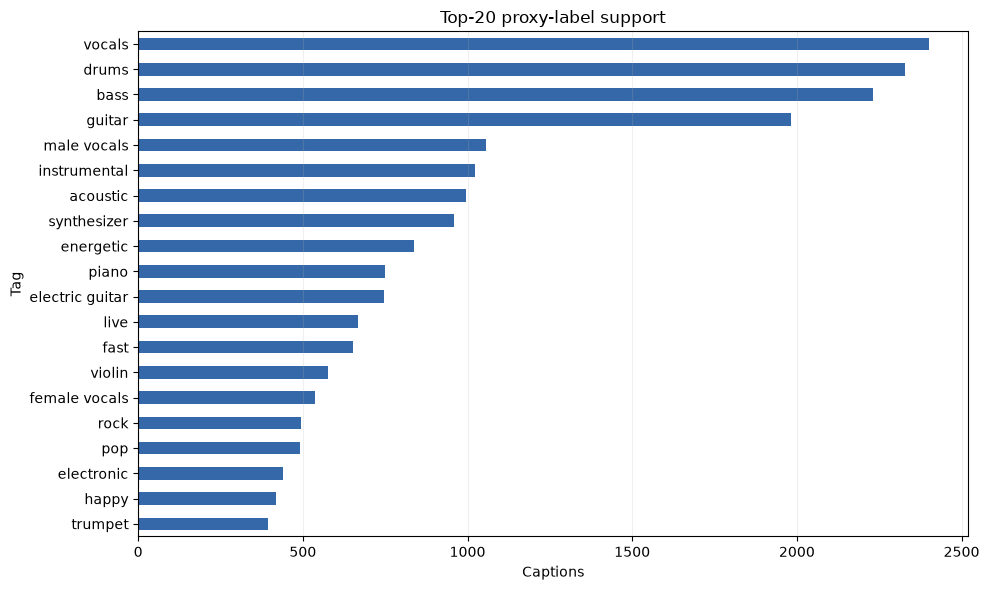

In [5]:
support = frame[label_names].sum().sort_values(ascending=False)
figure, axis = plt.subplots(figsize=(10, 6))
support.head(20).sort_values().plot.barh(ax=axis, color='#3568a8')
axis.set(title='Top-20 proxy-label support', xlabel='Captions', ylabel='Tag')
axis.grid(axis='x', alpha=0.2)
figure.tight_layout()

## 4. See how proxy labels are created

The preprocessing module applies case-insensitive regular expressions. This makes the data pipeline reproducible, but also creates direct target leakage because the matched word remains in the BERT input.

In [6]:
demo_captions = [
    'Energetic hip-hop with electric guitar, drums and female vocals',
    'A calm piano melody with no vocals',
    'Fast live jazz with saxophone and bass',
]
pd.DataFrame({'caption': demo_captions, 'matched_proxy_tags': [extract_tags(text) for text in demo_captions]})

,caption,matched_proxy_tags
0,"Energetic hip-hop with electric guitar, drums ...","[hip hop, energetic, guitar, drums, vocals, fe..."
1,A calm piano melody with no vocals,"[calm, piano, vocals]"
2,Fast live jazz with saxophone and bass,"[jazz, saxophone, bass, live, fast]"


Notice that `no vocals` still matches `vocals`; the fixed rules do not model negation.

## 5. Verify deterministic train/validation/test splits

The trainer rejects empty text, non-binary targets, and exact duplicate captions before creating a seeded, disjoint 70/15/15 split.

In [7]:
texts, labels, loaded_label_names = load_tag_data(DATA_PATH)
splits = make_split_indices(len(texts), val_size=0.15, test_size=0.15, seed=42)
all_indices = [index for values in splits.values() for index in values]
split_summary = pd.DataFrame({
    'split': list(splits),
    'samples': [len(splits[name]) for name in splits],
    'percentage': [100 * len(splits[name]) / len(texts) for name in splits],
})
assert len(all_indices) == len(set(all_indices)) == len(texts)
assert set(all_indices) == set(range(len(texts)))
display(split_summary)
print('Disjoint and exhaustive: yes')

,split,samples,percentage
0,train,3709,69.994339
1,validation,795,15.002831
2,test,795,15.002831


Disjoint and exhaustive: yes


## 6. Model architecture

```text
caption strings
    -> BERT tokenizer: input_ids + attention_mask [batch, 128]
    -> bert-base-uncased last_hidden_state [batch, 128, 768]
    -> select token 0 (CLS) [batch, 768]
    -> dropout
    -> linear layer [768, 50]
    -> 50 logits
    -> BCEWithLogitsLoss during training
    -> sigmoid + threshold during inference
```

Each output is independent; sigmoid is used instead of softmax because one caption may have many tags.

## 7. Artifact-integrity check

A metrics file and checkpoint should describe the same model family. This check prevents accidentally reporting one run's metrics with another run's weights.

In [8]:
frozen_metadata = json.loads(METADATA_PATH.read_text(encoding='utf-8'))
frozen_metrics = json.loads(METRICS_PATH.read_text(encoding='utf-8'))
print('Frozen checkpoint model:', frozen_metadata['model_name'])
print('Frozen tags:', len(frozen_metadata['tags']))
print('Frozen best epoch:', frozen_metadata['best_epoch'])

active_checkpoint = ROOT / 'results' / 'task1' / 'best_model.pt'
active_metrics = ROOT / 'results' / 'task1' / 'metrics.json'
if active_checkpoint.is_file() and active_metrics.is_file():
    checkpoint_info = torch.load(active_checkpoint, map_location='cpu', weights_only=True)
    metrics_info = json.loads(active_metrics.read_text(encoding='utf-8'))
    checkpoint_model = checkpoint_info.get('config', {}).get('model_name')
    metrics_model = metrics_info.get('config', {}).get('model_name')
    print('Active checkpoint model:', checkpoint_model)
    print('Active metrics model:', metrics_model)
    if checkpoint_model != metrics_model:
        print('WARNING: active checkpoint and metrics are from different runs; they are not used below.')

Frozen checkpoint model: bert-base-uncased
Frozen tags: 50
Frozen best epoch: 10


## 8. Measured learning curves and results

The values below are genuine outputs of the frozen lexical-proxy experiment. They must be reported with the leakage limitation.

,epoch,train_loss,val_loss,train_macro_f1,val_macro_f1,val_micro_f1
0,1,0.286137,0.132492,0.123669,0.282901,0.762419
1,2,0.087838,0.042789,0.521525,0.743622,0.951071
2,3,0.035614,0.020147,0.799268,0.898123,0.982676
3,4,0.018419,0.011486,0.921845,0.953329,0.990795
4,5,0.011540,0.008161,0.969608,0.978389,0.994311
5,6,0.008237,0.006906,0.982232,0.979192,0.994444
6,7,0.006281,0.005630,0.987431,0.981809,0.995736
7,8,0.005293,0.005098,0.990493,0.983377,0.995993
8,9,0.004535,0.004931,0.991839,0.987163,0.996124
9,10,0.004301,0.004740,0.991976,0.987171,0.996125


,metric,value
0,Macro-F1,0.9894
1,Micro-F1,0.9969
2,Macro precision,0.9995
3,Macro recall,0.9811


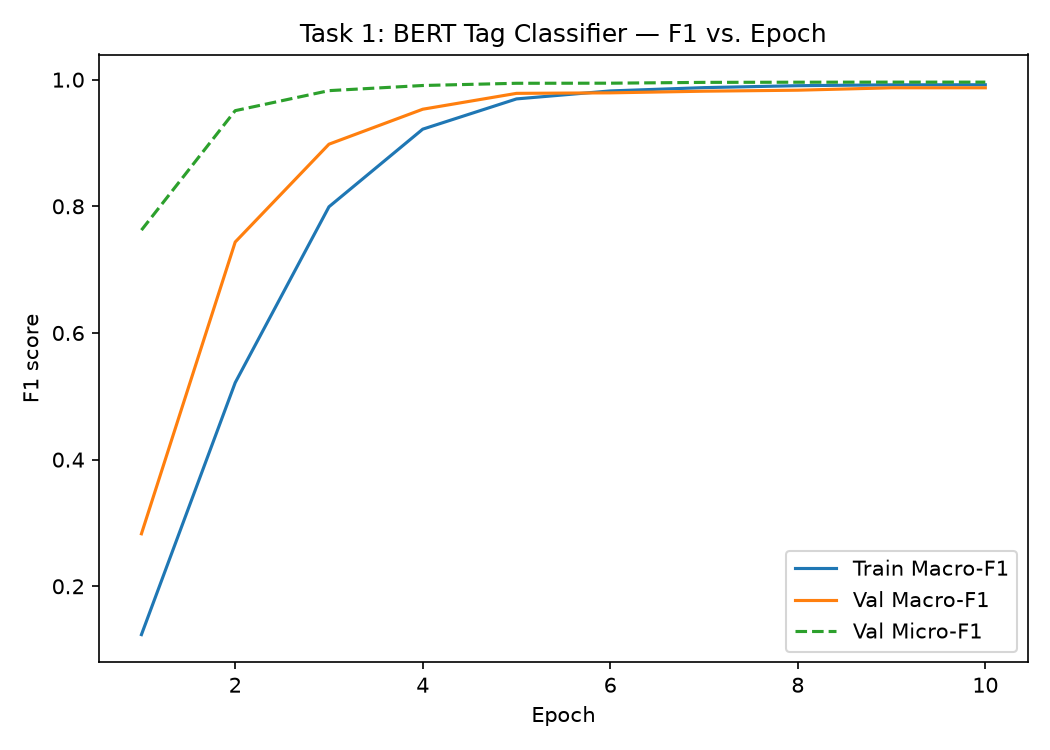

In [9]:
history = pd.DataFrame(frozen_metrics['history'])
display(history)
result_table = pd.DataFrame([
    {'metric': 'Macro-F1', 'value': frozen_metrics['test_macro_f1']},
    {'metric': 'Micro-F1', 'value': frozen_metrics['test_micro_f1']},
    {'metric': 'Macro precision', 'value': frozen_metrics['test_precision']},
    {'metric': 'Macro recall', 'value': frozen_metrics['test_recall']},
])
display(result_table.style.format({'value': '{:.4f}'}))
display(Image(filename=str(CURVE_PATH)))

## 9. Five saved qualitative examples

In [10]:
# Load examples here so this cell also works in a fresh kernel.
import json
from pathlib import Path

if 'EXAMPLES_PATH' not in globals():
    example_root = next((p for p in [Path.cwd(), *Path.cwd().parents] if (p / 'Task1_test' / 'files').is_dir()), None)
    if example_root is None:
        raise FileNotFoundError('Open this notebook from the Neural_Project folder or set EXAMPLES_PATH to example_predictions.json.')
    EXAMPLES_PATH = example_root / 'Task1_test' / 'files' / 'results' / 'example_predictions.json'
saved_examples = json.loads(Path(EXAMPLES_PATH).read_text(encoding='utf-8'))
def prediction_pairs(items):
    return [(item['tag'], item['probability']) if isinstance(item, dict) else item if isinstance(item, str) else tuple(item) for item in items]

for number, example in enumerate(saved_examples, start=1):
    print(f'Example {number}')
    print('Caption:', example['text'][:240] + ('...' if len(example['text']) > 240 else ''))
    print('True proxy tags:', example['true_tags'])
    print('Top predicted:', prediction_pairs(example['top_predicted']))
    print('-' * 80)

Example 1
Caption: This is the live performance of a Paraguayan folk music piece. There is no singer. There is a Paraguayan harp playing a vibrant yet melancholic tune. The atmosphere is heart-touching. This piece could be used in the soundtrack of a drama mo...
True proxy tags: ['vocals', 'live', 'folk', 'sad']
Top predicted: [('folk', 0.998), ('live', 0.995), ('sad', 0.994), ('vocals', 0.984), ('female vocals', 0.044)]
--------------------------------------------------------------------------------
Example 2
Caption: This is the sound of a didgeridoo being played. This sound alternates between a droning sound and a deep bass sound. There are no other instruments in this song. There are no voices in this song. This song can be played in a movie featuring...
True proxy tags: ['bass']
Top predicted: [('bass', 1.0), ('hip hop', 0.02), ('r&b', 0.002), ('angry', 0.001), ('instrumental', 0.001)]
--------------------------------------------------------------------------------
Example 3
Capti

## 10. Run checkpoint inference

This loads the frozen BERT-base checkpoint and may download `bert-base-uncased` tokenizer/config files if they are not already cached.

In [11]:
RUN_INFERENCE = True
inference_texts = [
    'calm acoustic guitar with soft vocals',
    'energetic electronic music with synthesizer and fast drums',
    'slow melancholic piano instrumental',
]
if RUN_INFERENCE:
    predictions = predict(
        inference_texts,
        CHECKPOINT_PATH,
        metadata_path=METADATA_PATH,
        device_name='auto',
        top_k=5,
    )
    display(pd.DataFrame({
        'caption': [item['text'] for item in predictions],
        'predicted_tags': [[tag['tag'] for tag in item['predicted_tags']] for item in predictions],
        'top_probabilities': [[(tag['tag'], tag['probability']) for tag in item['top_tags']] for item in predictions],
    }))
else:
    print('Inference skipped. Set RUN_INFERENCE = True when model files are available.')

Loading weights: 100%|██████████| 199/199 [00:00<00:00, 5008.05it/s]
[transformers] BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


,caption,predicted_tags,top_probabilities
0,calm acoustic guitar with soft vocals,"[acoustic, guitar, vocals, calm]","[(acoustic, 1.0), (guitar, 1.0), (vocals, 0.99..."
1,energetic electronic music with synthesizer an...,"[electronic, drums, synthesizer, fast, energetic]","[(electronic, 0.9999), (drums, 0.9999), (synth..."
2,slow melancholic piano instrumental,"[instrumental, piano, sad, slow]","[(instrumental, 1.0), (piano, 0.9997), (sad, 0..."


## 11. Optional retraining

Retraining is opt-in. When enabled, DistilBERT uses 10 epochs on CUDA or 2 on CPU and writes to results/task1/notebook_run/.

In [12]:
RUN_TRAINING = False
TRAIN_DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
TRAIN_EPOCHS = 10 if TRAIN_DEVICE == 'cuda' else 2
if RUN_TRAINING:
    notebook_metrics = train(Task1Config(
        data_path=str(DATA_PATH),
        output_dir=str(NOTEBOOK_RUN_DIR),
        model_name='distilbert-base-uncased',
        max_length=128,
        batch_size=16,
        epochs=TRAIN_EPOCHS,
        patience=3,
        seed=42,
        device=TRAIN_DEVICE,
    ))
    print('New run saved to:', NOTEBOOK_RUN_DIR)
else:
    print('Set RUN_TRAINING = True to train on the available CPU or GPU.')

Set RUN_TRAINING = True to train on the available CPU or GPU.


## 12. Interpretation checklist

Before submitting Task 1:

- State that targets are lexical proxies derived from the input caption.
- Do not describe the near-perfect F1 as audio or general semantic understanding.
- Keep checkpoint, metadata, metrics, curve, tag order, and split indices from one run together.
- Add label-prior, keyword, and TF-IDF controls for the final leakage analysis.
- Fit a publishable label vocabulary on training data only.
- Tune thresholds on validation only and keep test sealed until configuration freeze.
- Address negation errors such as `no vocals` before claiming robust tagging.